# Network Visualization and Bottleneck Analysis

This notebook analyzes the logistics network created in Notebook 02.

Objectives:
- Identify critical hubs
- Analyze network bottlenecks
- Visualize centrality metrics
- Generate business insights for ETA optimization

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load Corridor Dataset

In [2]:
corridors = pd.read_csv(
    "../data/processed/corridor_stats.csv"
)

corridors.head()

,source_center,destination_center,avg_actual_time,avg_osrm_time,trip_count,delay_ratio
0,IND000000AAL,IND411033AAA,63.702703,22.216216,37,2.867397
1,IND000000AAS,IND783370AAC,50.555556,25.888889,18,1.952790
2,IND000000ABA,IND683565AAA,30.846154,19.307692,13,1.597610
3,IND000000ABD,IND562132AAA,336.868056,201.986111,144,1.667778
4,IND000000ABG,IND501359AAF,111.170732,20.707317,41,5.368669


## Reconstruct Logistics Graph

In [3]:
G = nx.DiGraph()

for _, row in corridors.iterrows():

    G.add_edge(
        row["source_center"],
        row["destination_center"],
        weight=row["delay_ratio"]
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 1483
Edges: 2203


## Degree Centrality Analysis

In [4]:
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["hub", "degree_centrality"]
)

degree_df.head()

,hub,degree_centrality
0,IND000000AAL,0.00135
1,IND411033AAA,0.02834
2,IND000000AAS,0.00135
3,IND783370AAC,0.00135
4,IND000000ABA,0.00135


In [5]:
top_degree = degree_df.sort_values(
    by="degree_centrality",
    ascending=False
).head(20)

top_degree

,hub,degree_centrality
20,IND000000ACB,0.062078
7,IND562132AAA,0.047908
58,IND501359AAE,0.037787
19,IND160002AAC,0.037112
55,IND421302AAG,0.036437
88,IND110037AAM,0.028340
1,IND411033AAA,0.028340
61,IND712311AAA,0.027665
42,IND131028AAB,0.024291
60,IND600056AAB,0.022942


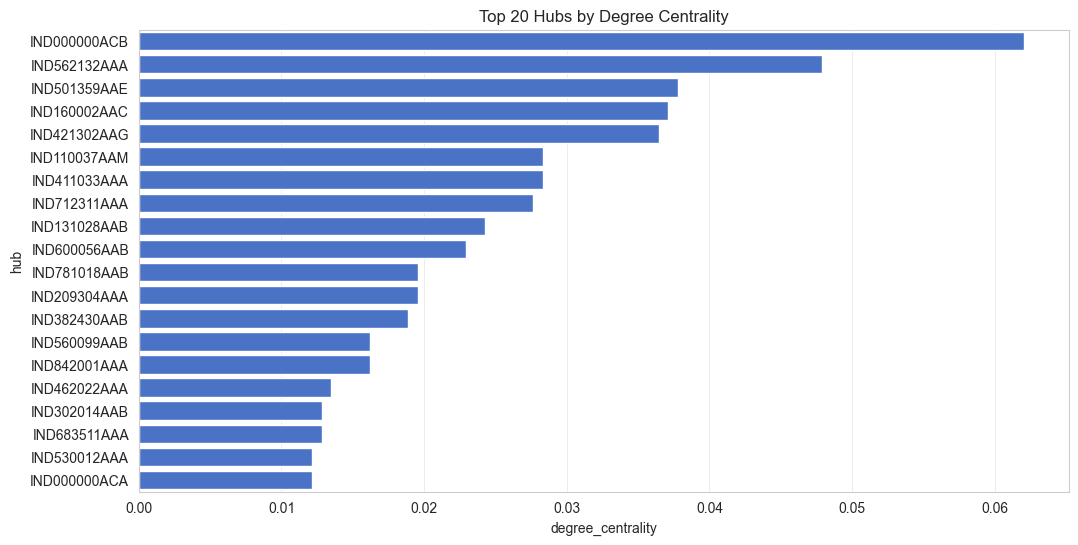

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_degree,
    x="degree_centrality",
    y="hub"
)

plt.title("Top 20 Hubs by Degree Centrality")

plt.show()

### Observation

These hubs have the highest connectivity in the logistics network and influence a large number of shipment routes.

## Betweenness Centrality Analysis

In [7]:
betweenness = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["hub", "betweenness"]
)

betweenness_df.head()

,hub,betweenness
0,IND000000AAL,0.000000
1,IND411033AAA,0.038914
2,IND000000AAS,0.000004
3,IND783370AAC,0.000004
4,IND000000ABA,0.000419


In [8]:
top_bottlenecks = betweenness_df.sort_values(
    by="betweenness",
    ascending=False
).head(20)

top_bottlenecks

,hub,betweenness
20,IND000000ACB,0.189313
7,IND562132AAA,0.110931
58,IND501359AAE,0.080381
61,IND712311AAA,0.062931
55,IND421302AAG,0.054761
19,IND160002AAC,0.045147
42,IND131028AAB,0.044809
1,IND411033AAA,0.038914
50,IND302014AAA,0.037062
60,IND600056AAB,0.036193


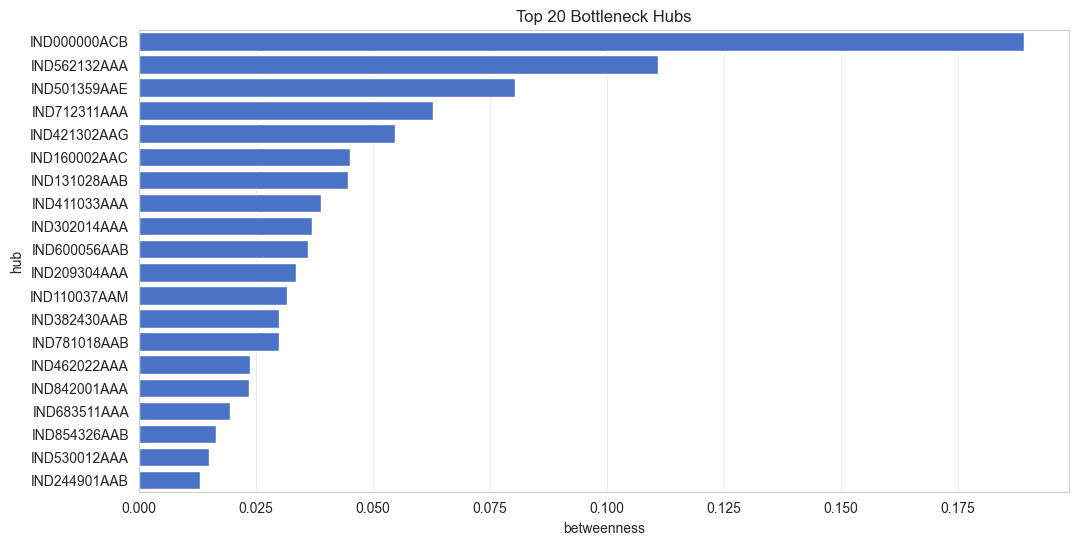

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_bottlenecks,
    x="betweenness",
    y="hub"
)

plt.title("Top 20 Bottleneck Hubs")

plt.show()

### Observation

These hubs act as critical bridges within the logistics network.

Disruptions at these locations can impact delivery performance across multiple corridors.

## Degree Centrality Distribution

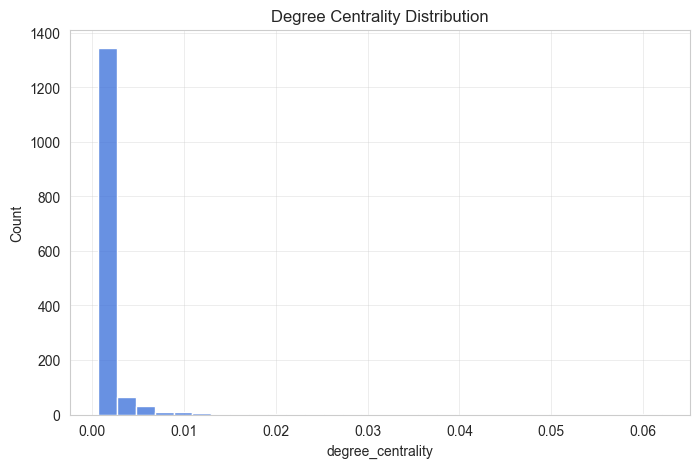

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    degree_df["degree_centrality"],
    bins=30
)

plt.title(
    "Degree Centrality Distribution"
)

plt.show()

## Betweenness Distribution

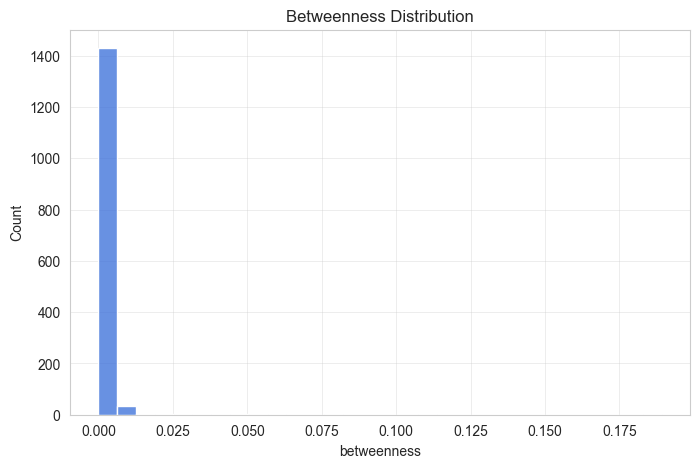

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    betweenness_df["betweenness"],
    bins=30
)

plt.title(
    "Betweenness Distribution"
)

plt.show()

## Key Findings

1. Highly connected hubs dominate network traffic.

2. Bottleneck hubs play a critical role in shipment movement.

3. Delays at central hubs may propagate through multiple routes.

4. These hubs should be prioritized for operational monitoring.

In [12]:
top_degree.to_csv(
    "../outputs/top_degree_hubs.csv",
    index=False
)

top_bottlenecks.to_csv(
    "../outputs/top_bottleneck_hubs.csv",
    index=False
)